# Global Superstore — Interactive Business Dashboard Analysis
**Task 5 | DevelopersHub Internship**

---
## Problem Statement & Objective
Develop an interactive dashboard for analyzing **sales, profit, and segment-wise performance** using the Global Superstore dataset.

**Goals:**
- Clean and prepare the dataset
- Perform Exploratory Data Analysis (EDA)
- Identify top customers, profitable categories, and regional performance
- Build visualizations to support business decisions

## 1. Import Libraries

In [7]:
!pip install plotly

In [8]:
!pip install plotly nbformat

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
sns.set_palette('Set2')
print('Libraries loaded ')

Libraries loaded 


## 2. Dataset Loading

In [10]:
df = pd.read_csv(
    r'F:\DevelopersHub_Intership\Interactive Business Dashboard in Streamlit\Global_Superstore2.csv',
    encoding='latin1'
)
df.columns = df.columns.str.strip()
print(f'Dataset Shape: {df.shape}')
df.head()

Dataset Shape: (51290, 24)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,28-01-2013,30-01-2013,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,...,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,05-11-2013,06-11-2013,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,...,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


## 3. Data Cleaning & Preprocessing

In [11]:
# ── Check missing values
print('Missing Values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# ── Drop rows missing critical fields
df.dropna(subset=['Sales', 'Profit'], inplace=True)

# ── Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True, errors='coerce')

# ── Numeric columns
for col in ['Sales', 'Profit', 'Quantity', 'Discount']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# ── Derived features
df['Year']          = df['Order Date'].dt.year
df['Month']         = df['Order Date'].dt.to_period('M').astype(str)
df['Profit Margin'] = (df['Profit'] / df['Sales'].replace(0, np.nan)) * 100
df['Ship Days']     = (df['Ship Date'] - df['Order Date']).dt.days

print(f'\nCleaned Dataset Shape: {df.shape}')
df.dtypes

Missing Values:
Postal Code    41296
dtype: int64

Cleaned Dataset Shape: (51290, 28)


Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
City                      object
State                     object
Country                   object
Postal Code              float64
Market                    object
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
Shipping Cost            float64
Order Priority            object
Year                       int32
Month                     object
Profit Margin            float64
Ship Days                  int64
dtype: object

In [12]:
# ── Summary statistics
df[['Sales','Profit','Quantity','Discount','Profit Margin','Ship Days']].describe().round(2)

,Sales,Profit,Quantity,Discount,Profit Margin,Ship Days
count,51290.00,51290.00,51290.00,51290.00,51290.00,51290.00
mean,246.49,28.61,3.48,0.14,4.74,3.97
std,487.57,174.34,2.28,0.21,46.57,1.73
min,0.44,-6599.98,1.00,0.00,-473.35,0.00
25%,30.76,0.00,2.00,0.00,0.00,3.00
50%,85.05,9.24,3.00,0.00,16.92,4.00
75%,251.05,36.81,5.00,0.20,33.31,5.00
max,22638.48,8399.98,14.00,0.85,50.00,7.00


## 4. Exploratory Data Analysis (EDA)

In [13]:
# ── KPIs
print('='*40)
print(f"  Total Sales    : ${df['Sales'].sum():>12,.2f}")
print(f"  Total Profit   : ${df['Profit'].sum():>12,.2f}")
print(f"  Total Orders   : {df['Order ID'].nunique():>13,}")
print(f"  Avg Margin     : {df['Profit Margin'].mean():>12.1f}%")
print(f"  Unique Customers: {df['Customer Name'].nunique():>12,}")
print('='*40)

  Total Sales    : $12,642,501.91
  Total Profit   : $1,467,457.29
  Total Orders   :        25,035
  Avg Margin     :          4.7%
  Unique Customers:          795


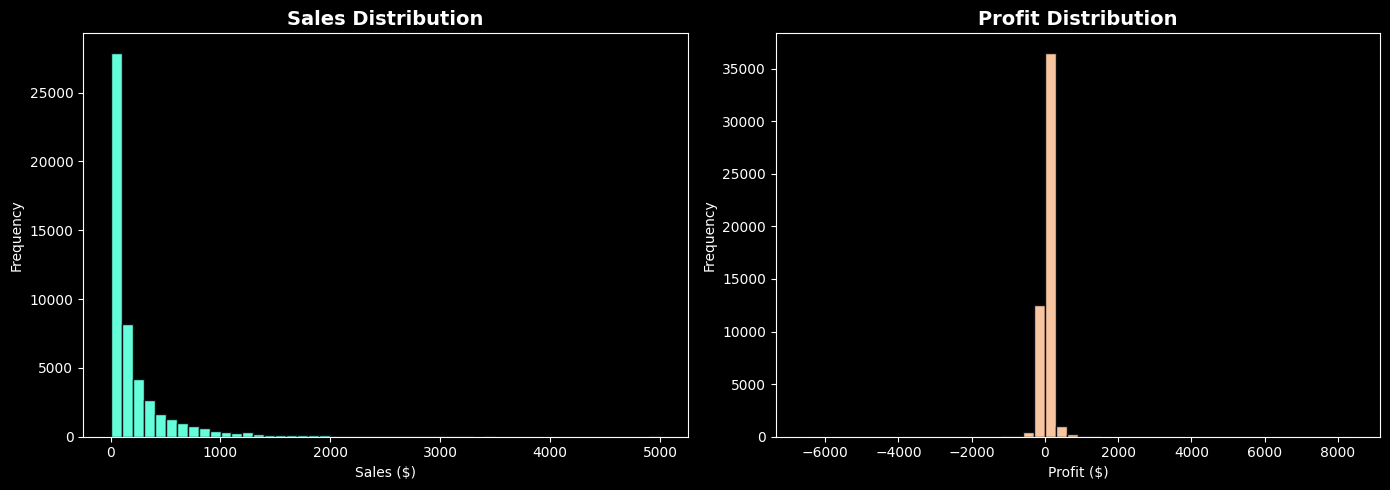

In [14]:
# ── 4.1 Sales Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['Sales'].clip(0, 5000), bins=50, color='#64ffda', edgecolor='#0f1117')
axes[0].set_title('Sales Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Profit'], bins=50, color='#f7c59f', edgecolor='#0f1117')
axes[1].set_title('Profit Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Profit ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

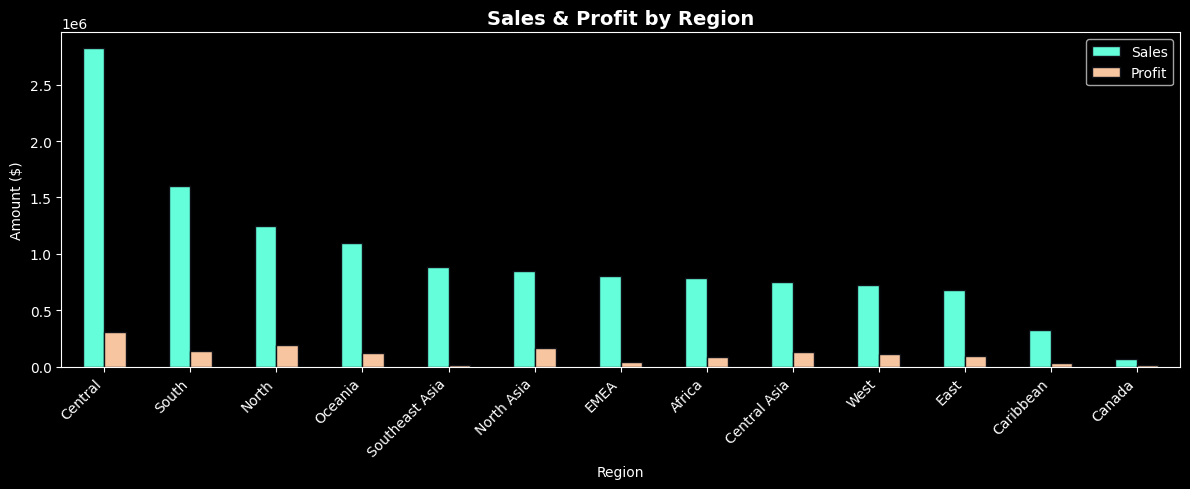

                     Sales     Profit
Region                               
Central         2822302.52  311403.98
South           1600907.04  140355.77
North           1248165.60  194597.95
Oceania         1100184.61  120089.11
Southeast Asia   884423.17   17852.33
North Asia       848309.78  165578.42
EMEA             806161.31   43897.97
Africa           783773.21   88871.63
Central Asia     752826.57  132480.19
West             725457.82  108418.45
East             678781.24   91522.78
Caribbean        324280.86   34571.32
Canada            66928.17   17817.39


In [15]:
# ── 4.2 Sales by Region
region = df.groupby('Region')[['Sales','Profit']].sum().sort_values('Sales', ascending=False)

region.plot(kind='bar', figsize=(12,5), color=['#64ffda','#f7c59f'], edgecolor='#0f1117')
plt.title('Sales & Profit by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()
print(region.round(2))

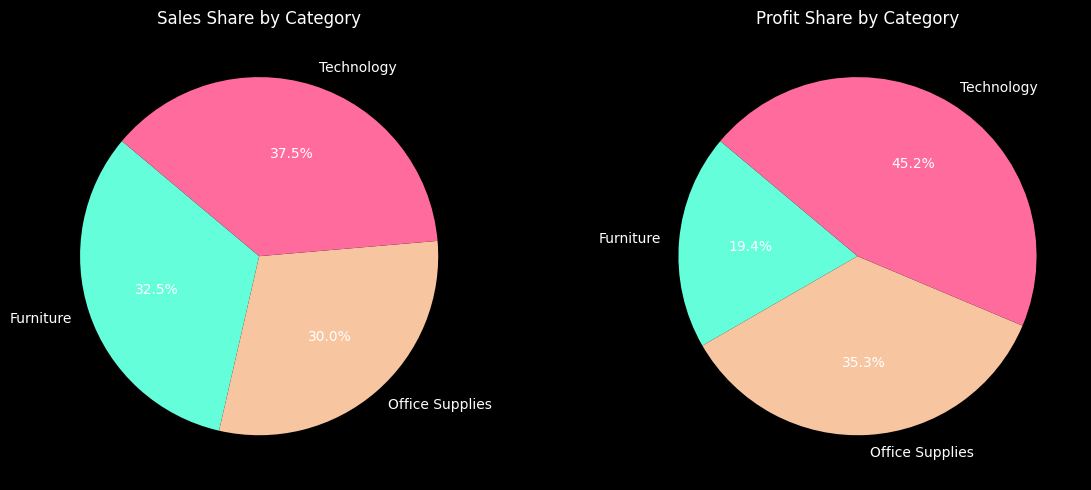

In [16]:
# ── 4.3 Sales by Category
cat = df.groupby('Category')[['Sales','Profit']].sum()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(cat['Sales'], labels=cat.index, autopct='%1.1f%%',
            colors=['#64ffda','#f7c59f','#ff6b9d'], startangle=140)
axes[0].set_title('Sales Share by Category')

axes[1].pie(cat['Profit'], labels=cat.index, autopct='%1.1f%%',
            colors=['#64ffda','#f7c59f','#ff6b9d'], startangle=140)
axes[1].set_title('Profit Share by Category')

plt.tight_layout()
plt.show()

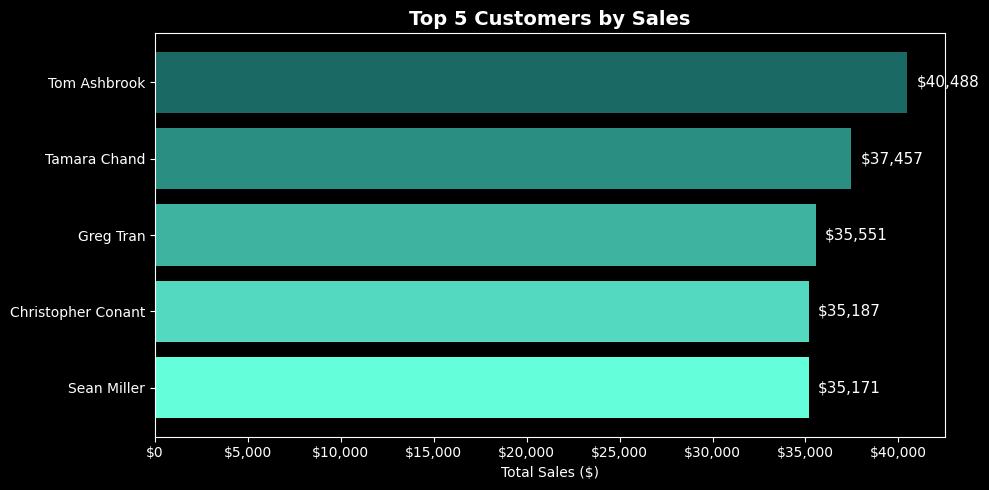

Customer Name
Tom Ashbrook          40488.07080
Tamara Chand          37457.33300
Greg Tran             35550.95428
Christopher Conant    35187.07640
Sean Miller           35170.93296
Name: Sales, dtype: float64


In [17]:
# ── 4.4 Top 5 Customers by Sales
top5 = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(5)

colors = ['#64ffda','#52d9bf','#3db3a0','#2a8e82','#1a6965']
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top5.index[::-1], top5.values[::-1], color=colors)
for bar, val in zip(bars, top5.values[::-1]):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=11, color='white')
ax.set_title('Top 5 Customers by Sales', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()
print(top5)

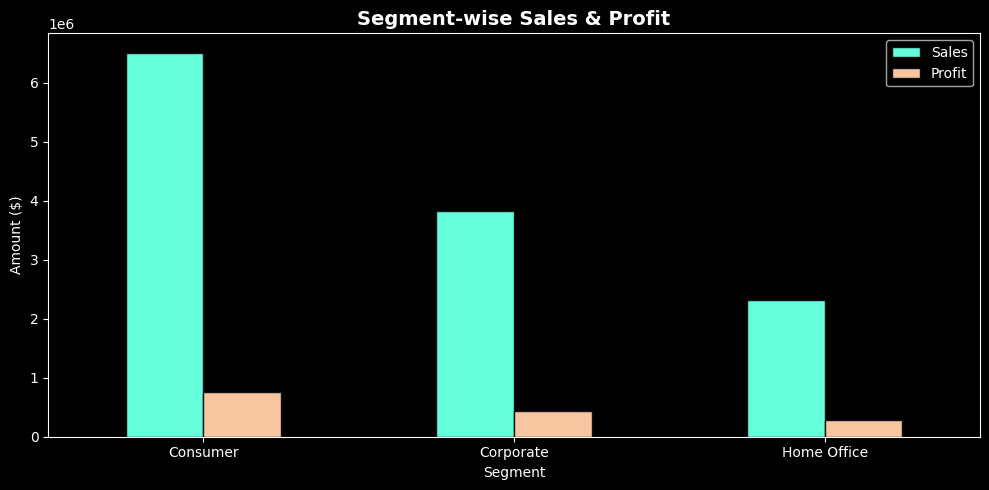

                  Sales     Profit  Quantity
Segment                                     
Consumer     6507949.42  749239.78     92157
Corporate    3824697.52  441208.33     53565
Home Office  2309854.97  277009.18     32590


In [18]:
# ── 4.5 Segment-wise Performance
seg = df.groupby('Segment')[['Sales','Profit','Quantity']].sum()

seg[['Sales','Profit']].plot(kind='bar', figsize=(10,5),
                              color=['#64ffda','#f7c59f'], edgecolor='#0f1117')
plt.title('Segment-wise Sales & Profit', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()
print(seg.round(2))

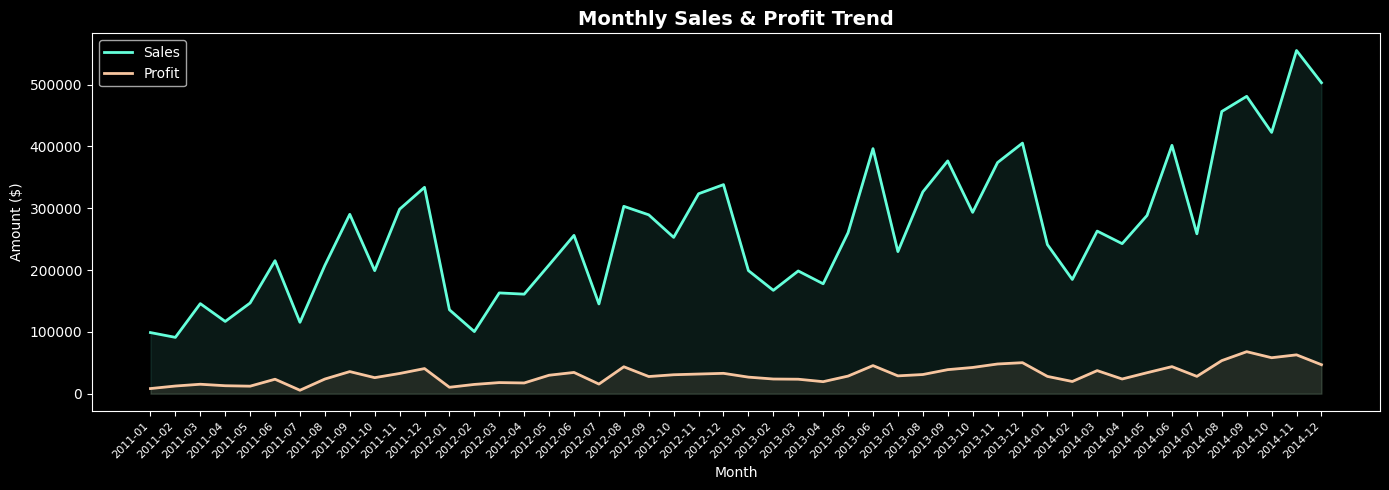

In [19]:
# ── 4.6 Monthly Sales Trend
monthly = df.groupby('Month')[['Sales','Profit']].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['Month'], monthly['Sales'],  color='#64ffda', linewidth=2, label='Sales')
ax.plot(monthly['Month'], monthly['Profit'], color='#f7c59f', linewidth=2, label='Profit')
ax.fill_between(monthly['Month'], monthly['Sales'],  alpha=0.1, color='#64ffda')
ax.fill_between(monthly['Month'], monthly['Profit'], alpha=0.1, color='#f7c59f')
ax.set_title('Monthly Sales & Profit Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

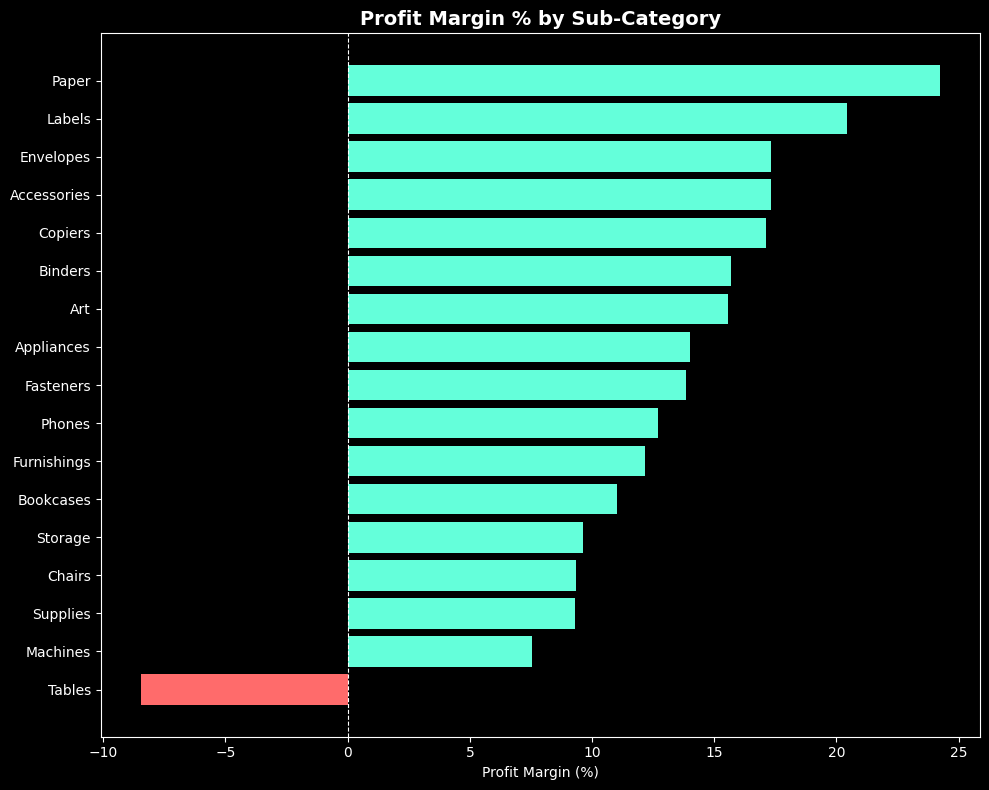

In [20]:
# ── 4.7 Profit Margin by Sub-Category
subcat = (df.groupby('Sub-Category')
          .apply(lambda x: (x['Profit'].sum() / x['Sales'].sum()) * 100)
          .reset_index(name='Margin %')
          .sort_values('Margin %', ascending=True))

colors = ['#ff6b6b' if v < 0 else '#64ffda' for v in subcat['Margin %']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(subcat['Sub-Category'], subcat['Margin %'], color=colors)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--')
ax.set_title('Profit Margin % by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

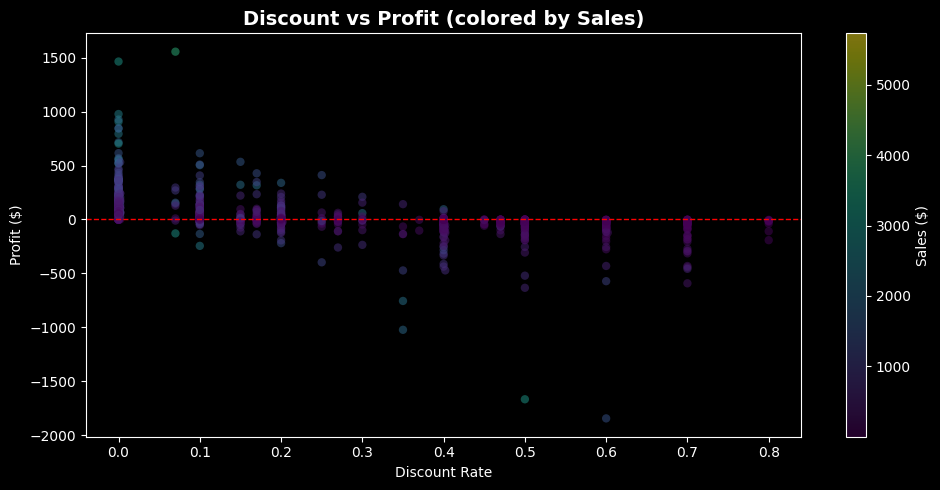

In [21]:
# ── 4.8 Discount vs Profit Scatter
sample = df.sample(min(2000, len(df)), random_state=42)
fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(sample['Discount'], sample['Profit'],
                     c=sample['Sales'], cmap='viridis', alpha=0.5, edgecolors='none')
plt.colorbar(scatter, ax=ax, label='Sales ($)')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_title('Discount vs Profit (colored by Sales)', fontsize=14, fontweight='bold')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
plt.tight_layout()
plt.show()

## 5. Key Insights & Conclusion

In [24]:
# ── Most & Least Profitable Sub-Categories
best  = subcat.tail(3)[['Sub-Category','Margin %']].values
worst = subcat.head(3)[['Sub-Category','Margin %']].values

print('TOP 3 MOST PROFITABLE SUB-CATEGORIES:')
for name, margin in best[::-1]:
    print(f'   {name}: {margin:.1f}%')

print('\nTOP 3 LEAST PROFITABLE SUB-CATEGORIES:')
for name, margin in worst:
    print(f'   {name}: {margin:.1f}%')

TOP 3 MOST PROFITABLE SUB-CATEGORIES:
   Paper: 24.2%
   Labels: 20.4%
   Envelopes: 17.3%

TOP 3 LEAST PROFITABLE SUB-CATEGORIES:
   Tables: -8.5%
   Machines: 7.6%
   Supplies: 9.3%


##  Final Conclusion

### Key Findings:

1. **Sales Performance** — The dataset shows consistent sales growth over the years, with seasonal peaks towards year-end (Q4).

2. **Regional Analysis** — Certain regions significantly outperform others in both sales and profit — targeted marketing in low-performing regions could unlock growth.

3. **Category Insights** — Technology leads in both sales and profit margins. Furniture, while high in sales, has lower profit margins due to high discounting.

4. **Discounting Problem** — A clear negative correlation exists between discount rate and profit. High discounts (>40%) almost always result in losses — discount strategy needs revision.

5. **Top Customers** — The top 5 customers contribute a significant portion of revenue. Retaining and upselling to these customers is high priority.

6. **Sub-Category Watch** — Some sub-categories (e.g. Tables, Bookcases) are consistently loss-making and should be reviewed for pricing or discontinuation.

### Recommendations:
- Reduce discounts especially in Furniture to improve margins
- Focus marketing on high-margin Technology products
- Invest in top-performing regions while developing underperforming ones
- Build a loyalty program for top customers